In [1]:
import pandas as pd
import numpy as np

# Créer un DataFrame — la structure de données centrale en data science
df = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie", "David", "Emma"],
    "age": [25, 30, 35, 28, 22],
    "salaire": [50000, 70000, 85000, 60000, 45000],
    "ville": ["Paris", "Lyon", "Paris", "Bordeaux", "Lyon"],
    "experience": [2, 5, 10, 4, 1]
})

# Exploration basique — toujours faire ça en premier sur un nouveau dataset
print("=== APERÇU ===")
print(df.head())        # 5 premières lignes

print("\n=== INFOS ===")
print(df.info())        # types, valeurs non-null

print("\n=== STATISTIQUES ===")
print(df.describe())    # statistiques descriptives

print("\n=== DIMENSIONS ===")
print(f"Shape : {df.shape}")        # (lignes, colonnes)
print(f"Colonnes : {list(df.columns)}")
print(f"Types :\n{df.dtypes}")

=== APERÇU ===
       nom  age  salaire     ville  experience
0    Alice   25    50000     Paris           2
1      Bob   30    70000      Lyon           5
2  Charlie   35    85000     Paris          10
3    David   28    60000  Bordeaux           4
4     Emma   22    45000      Lyon           1

=== INFOS ===
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   nom         5 non-null      str  
 1   age         5 non-null      int64
 2   salaire     5 non-null      int64
 3   ville       5 non-null      str  
 4   experience  5 non-null      int64
dtypes: int64(3), str(2)
memory usage: 332.0 bytes
None

=== STATISTIQUES ===
             age       salaire  experience
count   5.000000      5.000000    5.000000
mean   28.000000  62000.000000    4.400000
std     4.949747  16046.806536    3.507136
min    22.000000  45000.000000    1.000000
25%    25.000000  50000.000000   

In [2]:
# SÉLECTION ET FILTRAGE

# Sélectionner une colonne
print("=== UNE COLONNE ===")
print(df["nom"])

print("\n=== PLUSIEURS COLONNES ===")
print(df[["nom", "salaire"]])

print("\n=== LIGNE PAR INDEX ===")
print(df.iloc[0])    # première ligne
print(df.iloc[-1])   # dernière ligne

print("\n=== FILTRAGE ===")
# Personnes de plus de 25 ans
print(df[df["age"] > 25])

# Personnes à Paris
print(df[df["ville"] == "Paris"])

# Plusieurs conditions
print(df[(df["age"] > 25) & (df["salaire"] > 60000)])

# Villes dans une liste
print(df[df["ville"].isin(["Paris", "Lyon"])])

=== UNE COLONNE ===
0      Alice
1        Bob
2    Charlie
3      David
4       Emma
Name: nom, dtype: str

=== PLUSIEURS COLONNES ===
       nom  salaire
0    Alice    50000
1      Bob    70000
2  Charlie    85000
3    David    60000
4     Emma    45000

=== LIGNE PAR INDEX ===
nom           Alice
age              25
salaire       50000
ville         Paris
experience        2
Name: 0, dtype: object
nom            Emma
age              22
salaire       45000
ville          Lyon
experience        1
Name: 4, dtype: object

=== FILTRAGE ===
       nom  age  salaire     ville  experience
1      Bob   30    70000      Lyon           5
2  Charlie   35    85000     Paris          10
3    David   28    60000  Bordeaux           4
       nom  age  salaire  ville  experience
0    Alice   25    50000  Paris           2
2  Charlie   35    85000  Paris          10
       nom  age  salaire  ville  experience
1      Bob   30    70000   Lyon           5
2  Charlie   35    85000  Paris          10
    

In [3]:
# MODIFICATION DU DATAFRAME

# Ajouter une colonne calculée
df["salaire_mensuel"] = df["salaire"] / 12
df["bonus"] = df["salaire"] * 0.1

# Catégoriser avec apply
df["niveau"] = df["experience"].apply(
    lambda x: "Senior" if x >= 5 else "Junior"
)

print("=== DATAFRAME MODIFIÉ ===")
print(df)

print("\n=== STATISTIQUES PAR VILLE ===")
print(df.groupby("ville")["salaire"].mean())

print("\n=== GROUPBY AVANCÉ ===")
print(df.groupby("ville").agg({
    "salaire": ["mean", "max"],
    "age": "mean",
    "nom": "count"
}))

print("\n=== TRI ===")
print(df.sort_values("salaire", ascending=False)[["nom", "salaire", "niveau"]])

=== DATAFRAME MODIFIÉ ===
       nom  age  salaire     ville  experience  salaire_mensuel   bonus  \
0    Alice   25    50000     Paris           2      4166.666667  5000.0   
1      Bob   30    70000      Lyon           5      5833.333333  7000.0   
2  Charlie   35    85000     Paris          10      7083.333333  8500.0   
3    David   28    60000  Bordeaux           4      5000.000000  6000.0   
4     Emma   22    45000      Lyon           1      3750.000000  4500.0   

   niveau  
0  Junior  
1  Senior  
2  Senior  
3  Junior  
4  Junior  

=== STATISTIQUES PAR VILLE ===
ville
Bordeaux    60000.0
Lyon        57500.0
Paris       67500.0
Name: salaire, dtype: float64

=== GROUPBY AVANCÉ ===
          salaire          age   nom
             mean    max  mean count
ville                               
Bordeaux  60000.0  60000  28.0     1
Lyon      57500.0  70000  26.0     2
Paris     67500.0  85000  30.0     2

=== TRI ===
       nom  salaire  niveau
2  Charlie    85000  Senior
1      B

In [5]:
# VALEURS MANQUANTES — problème #1 en data science

# Créer un dataset avec des valeurs manquantes
df_nan = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie", "David", "Emma"],
    "age": [25, None, 35, 28, None],
    "salaire": [50000, 70000, None, 60000, 45000],
    "ville": ["Paris", None, "Paris", "Bordeaux", "Lyon"]
})

print("=== DATASET AVEC NaN ===")
print(df_nan)

print("\n=== DÉTECTER LES NaN ===")
print(df_nan.isnull())

print("\n=== COMPTER LES NaN PAR COLONNE ===")
print(df_nan.isnull().sum())

print("\n=== POURCENTAGE DE NaN ===")
print(df_nan.isnull().mean() * 100)

print("\n=== STRATÉGIES DE TRAITEMENT ===")

# 1. Supprimer les lignes avec NaN
df_drop = df_nan.dropna()
print(f"Après dropna() : {len(df_drop)} lignes restantes")

# 2. Remplir avec la moyenne
df_fill = df_nan.copy()
df_fill["age"] = df_fill["age"].fillna(df_fill["age"].mean())
df_fill["salaire"] = df_fill["salaire"].fillna(df_fill["salaire"].median())
df_fill["ville"] = df_fill["ville"].fillna("Inconnu")

print("\nAprès fillna() :")
print(df_fill)

=== DATASET AVEC NaN ===
       nom   age  salaire     ville
0    Alice  25.0  50000.0     Paris
1      Bob   NaN  70000.0       NaN
2  Charlie  35.0      NaN     Paris
3    David  28.0  60000.0  Bordeaux
4     Emma   NaN  45000.0      Lyon

=== DÉTECTER LES NaN ===
     nom    age  salaire  ville
0  False  False    False  False
1  False   True    False   True
2  False  False     True  False
3  False  False    False  False
4  False   True    False  False

=== COMPTER LES NaN PAR COLONNE ===
nom        0
age        2
salaire    1
ville      1
dtype: int64

=== POURCENTAGE DE NaN ===
nom         0.0
age        40.0
salaire    20.0
ville      20.0
dtype: float64

=== STRATÉGIES DE TRAITEMENT ===
Après dropna() : 2 lignes restantes

Après fillna() :
       nom        age  salaire     ville
0    Alice  25.000000  50000.0     Paris
1      Bob  29.333333  70000.0   Inconnu
2  Charlie  35.000000  55000.0     Paris
3    David  28.000000  60000.0  Bordeaux
4     Emma  29.333333  45000.0      Lyo

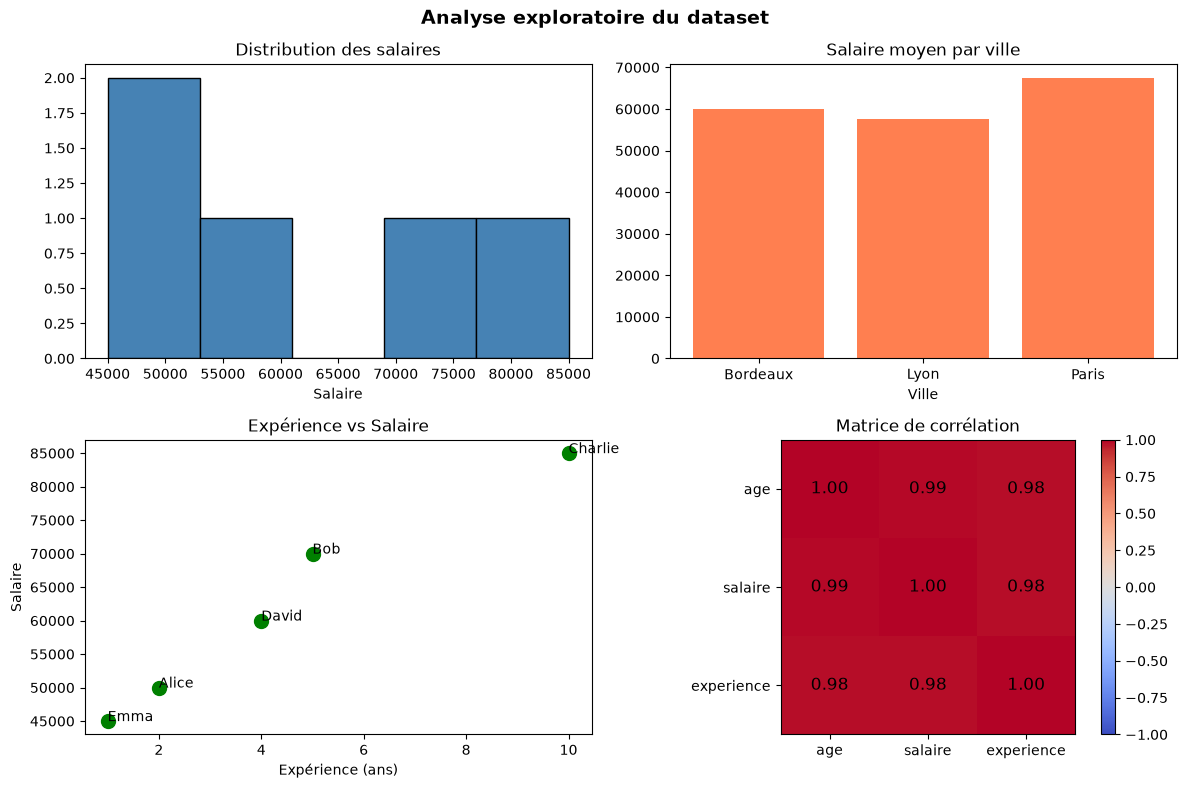

In [6]:
import matplotlib.pyplot as plt

# Recréer le dataframe propre
df = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie", "David", "Emma"],
    "age": [25, 30, 35, 28, 22],
    "salaire": [50000, 70000, 85000, 60000, 45000],
    "ville": ["Paris", "Lyon", "Paris", "Bordeaux", "Lyon"],
    "experience": [2, 5, 10, 4, 1]
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Distribution des salaires
axes[0,0].hist(df["salaire"], bins=5, color="steelblue", edgecolor="black")
axes[0,0].set_title("Distribution des salaires")
axes[0,0].set_xlabel("Salaire")

# 2. Salaire par ville
salaire_ville = df.groupby("ville")["salaire"].mean()
axes[0,1].bar(salaire_ville.index, salaire_ville.values, color="coral")
axes[0,1].set_title("Salaire moyen par ville")
axes[0,1].set_xlabel("Ville")

# 3. Experience vs Salaire
axes[1,0].scatter(df["experience"], df["salaire"], 
                  color="green", s=100)
for i, nom in enumerate(df["nom"]):
    axes[1,0].annotate(nom, (df["experience"][i], df["salaire"][i]))
axes[1,0].set_title("Expérience vs Salaire")
axes[1,0].set_xlabel("Expérience (ans)")
axes[1,0].set_ylabel("Salaire")

# 4. Matrice de corrélation
corr = df[["age", "salaire", "experience"]].corr()
im = axes[1,1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(corr.columns)))
axes[1,1].set_yticks(range(len(corr.columns)))
axes[1,1].set_xticklabels(corr.columns)
axes[1,1].set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1,1].text(j, i, f"{corr.iloc[i,j]:.2f}", 
                      ha="center", va="center", fontsize=12)
axes[1,1].set_title("Matrice de corrélation")
plt.colorbar(im, ax=axes[1,1])

plt.suptitle("Analyse exploratoire du dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/ry/h4ry2cz578997qqf7j5s7rmw0000gn/T/ipykernel_45792/1625370776.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="niveau", y="salaire",
/var/folders/ry/h4ry2cz578997qqf7j5s7rmw0000gn/T/ipykernel_45792/1625370776.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="ville", y="salaire",


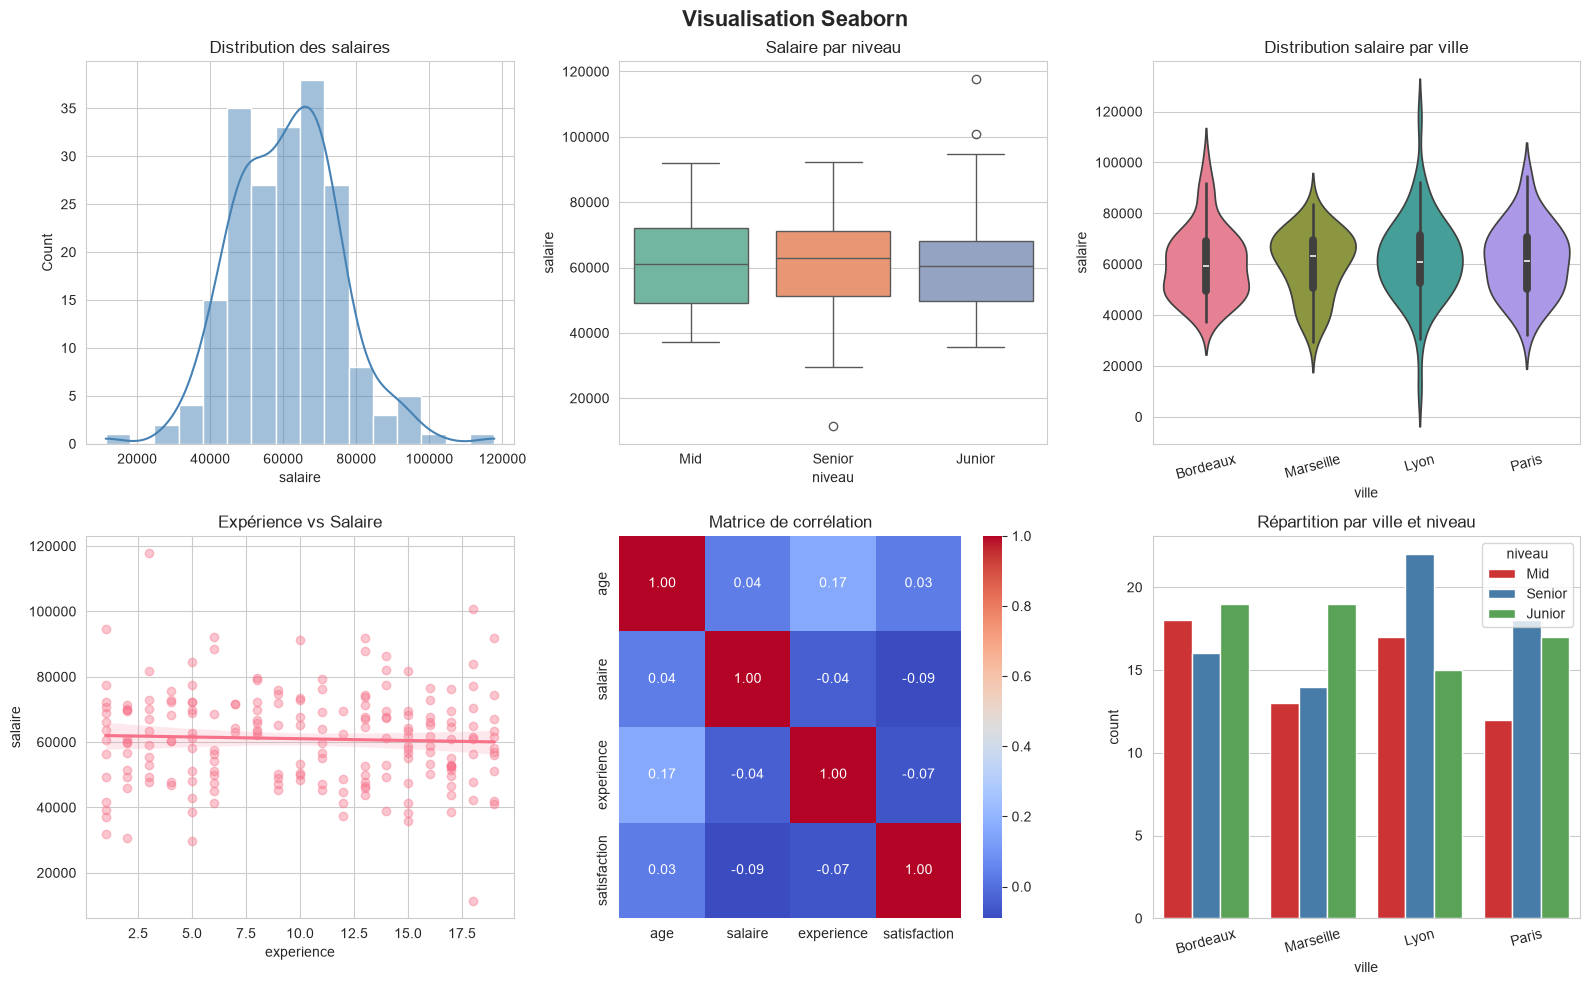

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# SEABORN — visualisation statistique avancée
sns.set_style("whitegrid")
sns.set_palette("husl")

# Dataset
np.random.seed(42)
df = pd.DataFrame({
    "age":        np.random.randint(22, 55, 200),
    "salaire":    np.random.normal(60000, 15000, 200),
    "experience": np.random.randint(1, 20, 200),
    "ville":      np.random.choice(["Paris", "Lyon", "Bordeaux", "Marseille"], 200),
    "niveau":     np.random.choice(["Junior", "Mid", "Senior"], 200),
    "satisfaction": np.random.randint(1, 11, 200)
})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribution avec KDE
sns.histplot(data=df, x="salaire", kde=True, 
             color="steelblue", ax=axes[0,0])
axes[0,0].set_title("Distribution des salaires")

# 2. Boxplot par groupe
sns.boxplot(data=df, x="niveau", y="salaire", 
            palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Salaire par niveau")

# 3. Violin plot
sns.violinplot(data=df, x="ville", y="salaire",
               palette="husl", ax=axes[0,2])
axes[0,2].set_title("Distribution salaire par ville")
axes[0,2].tick_params(axis='x', rotation=15)

# 4. Scatter avec régression
sns.regplot(data=df, x="experience", y="salaire",
            scatter_kws={"alpha": 0.4}, ax=axes[1,0])
axes[1,0].set_title("Expérience vs Salaire")

# 5. Heatmap corrélation
corr = df[["age", "salaire", "experience", "satisfaction"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", 
            fmt=".2f", ax=axes[1,1])
axes[1,1].set_title("Matrice de corrélation")

# 6. Countplot
sns.countplot(data=df, x="ville", hue="niveau",
              palette="Set1", ax=axes[1,2])
axes[1,2].set_title("Répartition par ville et niveau")
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle("Visualisation Seaborn", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

=== DATASET ORIGINAL ===
   age       salaire  experience date_embauche
0   52  58034.423895           5    2010-01-31
1   42  29471.396391           9    2010-02-28
2   38  70981.854110           2    2010-03-31

=== APRÈS FEATURE ENGINEERING ===
   age       salaire  experience date_embauche  salaire_log  age_squared  salaire_par_annee  annee_embauche  mois_embauche  anciennete tranche_age  age_x_experience
0   52  58034.423895           5    2010-01-31    10.968792         2704       11606.884779            2010              1          16      Senior               260
1   42  29471.396391           9    2010-02-28    10.291175         1764        3274.599599            2010              2          16      Senior               378
2   38  70981.854110           2    2010-03-31    11.170180         1444       35490.927055            2010              3          16      Adulte                76

Nombre de features : 12


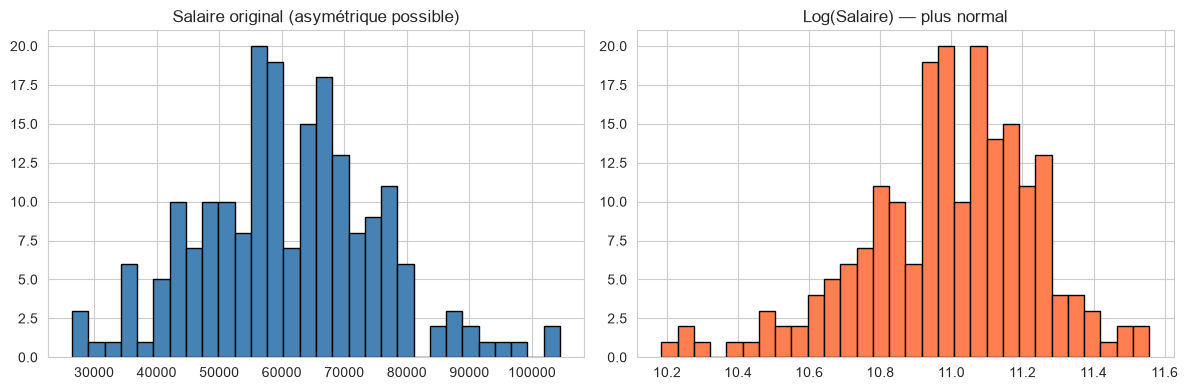

In [2]:
# FEATURE ENGINEERING — créer de nouvelles features

df_fe = pd.DataFrame({
    "age":        np.random.randint(22, 55, 200),
    "salaire":    np.random.normal(60000, 15000, 200),
    "experience": np.random.randint(1, 20, 200),
    "date_embauche": pd.date_range("2010-01-01", periods=200, freq="ME")
})

print("=== DATASET ORIGINAL ===")
print(df_fe.head(3))

# 1. Features mathématiques
df_fe["salaire_log"] = np.log(df_fe["salaire"].clip(1))  # log transform
df_fe["age_squared"] = df_fe["age"] ** 2
df_fe["salaire_par_annee"] = df_fe["salaire"] / df_fe["experience"]

# 2. Features à partir des dates
df_fe["annee_embauche"] = df_fe["date_embauche"].dt.year
df_fe["mois_embauche"] = df_fe["date_embauche"].dt.month
df_fe["anciennete"] = 2026 - df_fe["annee_embauche"]

# 3. Binning (discrétisation)
df_fe["tranche_age"] = pd.cut(
    df_fe["age"],
    bins=[0, 30, 40, 100],
    labels=["Jeune", "Adulte", "Senior"]
)

# 4. Features d'interaction
df_fe["age_x_experience"] = df_fe["age"] * df_fe["experience"]

print("\n=== APRÈS FEATURE ENGINEERING ===")
print(df_fe.head(3).to_string())
print(f"\nNombre de features : {df_fe.shape[1]}")

# Visualiser l'impact du log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_fe["salaire"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Salaire original (asymétrique possible)")
axes[1].hist(df_fe["salaire_log"], bins=30, color="coral", edgecolor="black")
axes[1].set_title("Log(Salaire) — plus normal")
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np

# CROSS-VALIDATION
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("=== CROSS-VALIDATION (5-Fold) ===")
print(f"Scores par fold : {scores.round(4)}")
print(f"Moyenne : {scores.mean():.4f}")
print(f"Écart-type : {scores.std():.4f}")
print(f"→ {scores.mean():.4f} ± {scores.std():.4f}")

print("\n=== PIPELINE SCIKIT-LEARN ===")
# Dataset mixte (numérique + catégoriel)
import pandas as pd
np.random.seed(42)
n = 500
df_pipe = pd.DataFrame({
    "age":      np.random.randint(20, 60, n),
    "salaire":  np.random.normal(50000, 10000, n),
    "ville":    np.random.choice(["Paris", "Lyon", "Bordeaux"], n),
    "niveau":   np.random.choice(["Junior", "Senior"], n),
    "target":   np.random.randint(0, 2, n)
})

# Introduire des NaN
df_pipe.loc[np.random.choice(n, 50), "age"] = np.nan
df_pipe.loc[np.random.choice(n, 30), "salaire"] = np.nan

X_pipe = df_pipe.drop("target", axis=1)
y_pipe = df_pipe["target"]

# Colonnes numériques et catégorielles
num_features = ["age", "salaire"]
cat_features = ["ville", "niveau"]

# Transformateurs
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

# Pipeline complet
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Cross-validation sur le pipeline
scores_pipe = cross_val_score(pipeline, X_pipe, y_pipe, cv=5, scoring="accuracy")
print(f"Pipeline CV Score : {scores_pipe.mean():.4f} ± {scores_pipe.std():.4f}")
print("\n✅ Le Pipeline gère automatiquement :")
print("   - Les valeurs manquantes (imputation)")
print("   - La normalisation des numériques")
print("   - L'encodage des catégorielles")
print("   - La cross-validation sans data leakage")

=== CROSS-VALIDATION (5-Fold) ===
Scores par fold : [0.88  0.915 0.92  0.93  0.905]
Moyenne : 0.9100
Écart-type : 0.0170
→ 0.9100 ± 0.0170

=== PIPELINE SCIKIT-LEARN ===
Pipeline CV Score : 0.5440 ± 0.0393

✅ Le Pipeline gère automatiquement :
   - Les valeurs manquantes (imputation)
   - La normalisation des numériques
   - L'encodage des catégorielles
   - La cross-validation sans data leakage


In [2]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# PLOTLY — graphiques interactifs
# Contrairement à Matplotlib/Seaborn, Plotly est interactif
# Tu peux zoomer, survoler, filtrer directement dans le graphique

np.random.seed(42)
df = pd.DataFrame({
    "age":        np.random.randint(22, 55, 200),
    "salaire":    np.random.normal(60000, 15000, 200),
    "experience": np.random.randint(1, 20, 200),
    "ville":      np.random.choice(["Paris", "Lyon", "Bordeaux", "Marseille"], 200),
    "niveau":     np.random.choice(["Junior", "Mid", "Senior"], 200),
})

# 1. Scatter interactif
fig1 = px.scatter(
    df, x="experience", y="salaire",
    color="niveau", size="age",
    hover_data=["ville"],
    title="Expérience vs Salaire (interactif)",
    labels={"experience": "Expérience (ans)", "salaire": "Salaire (€)"}
)
fig1.show()

# 2. Bar chart
fig2 = px.bar(
    df.groupby("ville")["salaire"].mean().reset_index(),
    x="ville", y="salaire",
    color="ville",
    title="Salaire moyen par ville",
    text_auto=".0f"
)
fig2.show()

# 3. Box plot interactif
fig3 = px.box(
    df, x="niveau", y="salaire",
    color="niveau",
    title="Distribution salaire par niveau",
    points="all"
)
fig3.show()

# 4. Histogram avec slider
fig4 = px.histogram(
    df, x="salaire", color="niveau",
    nbins=30, barmode="overlay",
    title="Distribution des salaires par niveau",
    opacity=0.7
)
fig4.show()

print("✅ 4 graphiques Plotly interactifs créés !")
print("→ Tu peux zoomer, survoler, cliquer sur la légende pour filtrer")

✅ 4 graphiques Plotly interactifs créés !
→ Tu peux zoomer, survoler, cliquer sur la légende pour filtrer
